<a href="https://colab.research.google.com/github/rohitpeets/Data-Extraction-Pipeines-Document-RAG-Agent/blob/main/DataProcessing_pipe2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pytesseract opencv-python-headless numpy pillow --break-system-packages
!pip install pymupdf
!apt-get install -y tesseract-ocr


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 4 not upgraded.


In [ ]:
import io
import cv2
import fitz
import numpy as np
import re
import json
import pytesseract
from PIL import Image

---Page 1 ----
e cytiva te Wes y 100 Results Way Marlborough, MA 01752 USA Regarding: Animal origin statement for AKTA™ Ready Products It is hereby stated that the materials in the fluid path of the products listed below are animal origin free or comply with EMA 410/01 Rev 3. Product/Part name Product code High Flow Gradient C, Modified, AKTA ready 29-1846-12 Cytiva appreciates the opportunity to serve our valued customers and is dedicated to improving our capabilities to manufacture and deliver products and services that meet or exceed your needs consistently. Date: a<f- ad 19 March 2021 ae A Name: Sa fr Title Susan Bouctier Regulatory Support Manager The information herein is provided to the best of our knowledge and belief, based on the information we have been given and the information available to us at the time that this document was issued. The information may change as additional facts come to light, or as the circumstances warrant. Your use hereof is hence at your own risk and

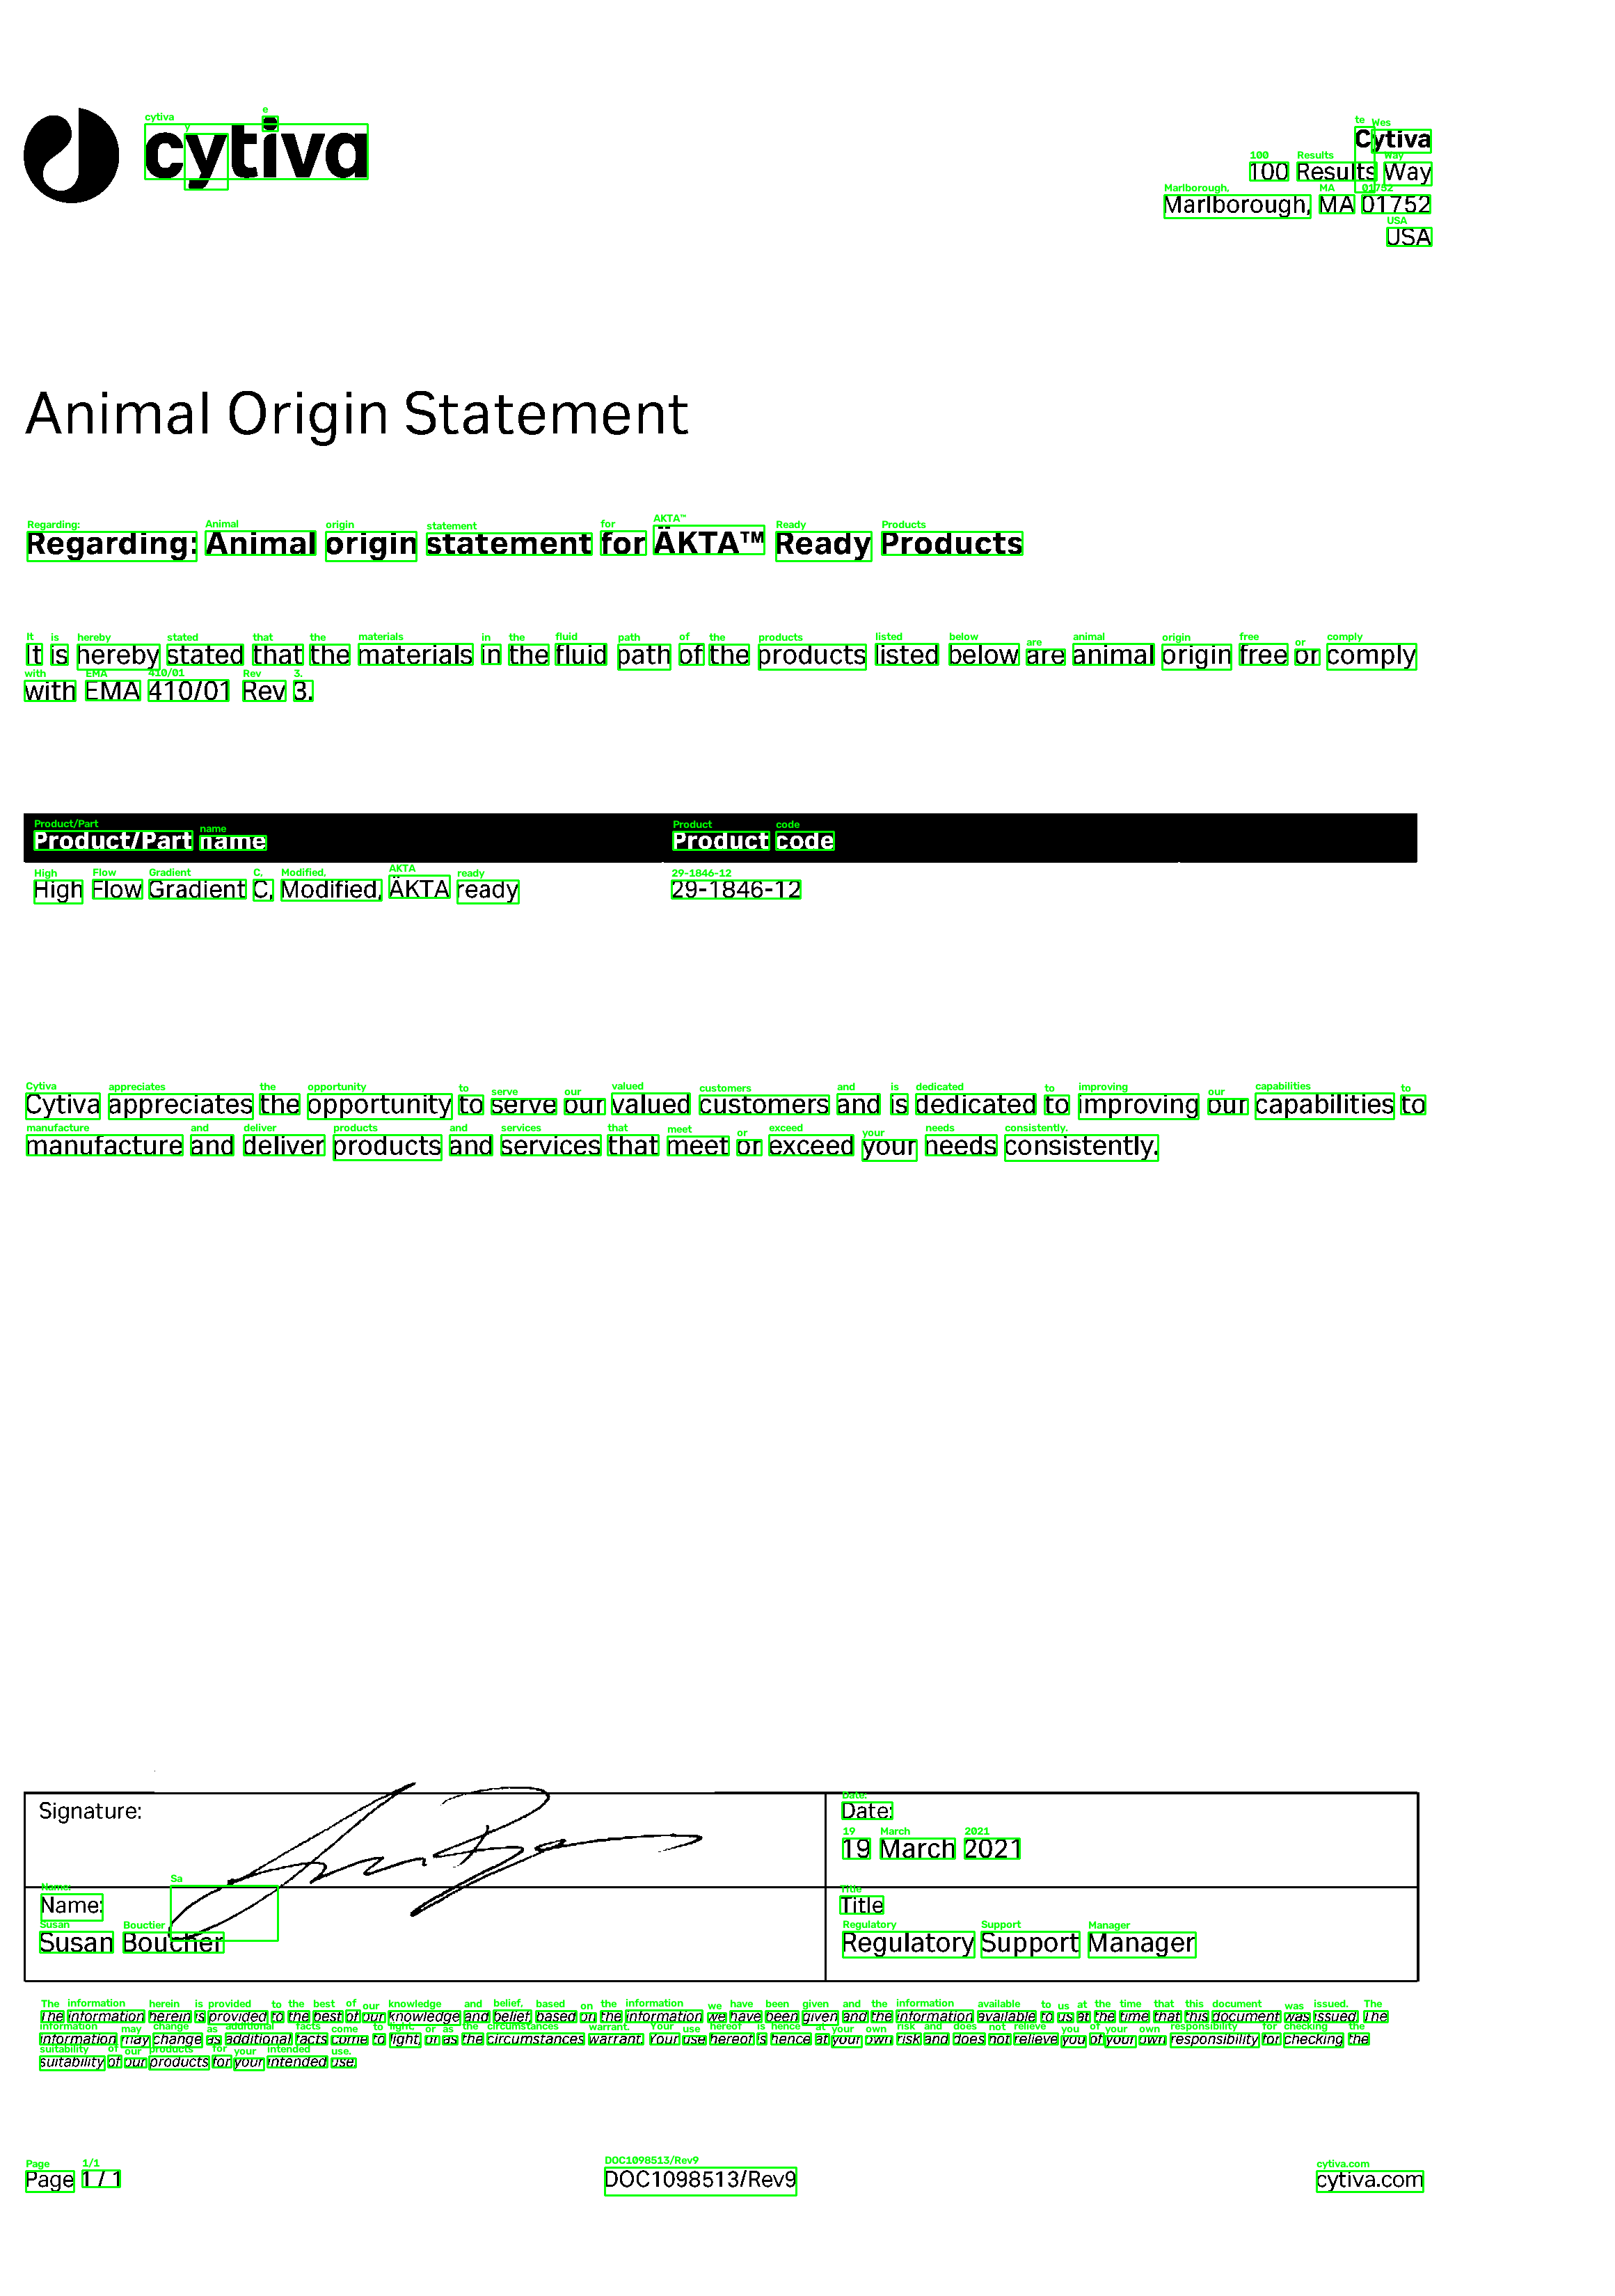

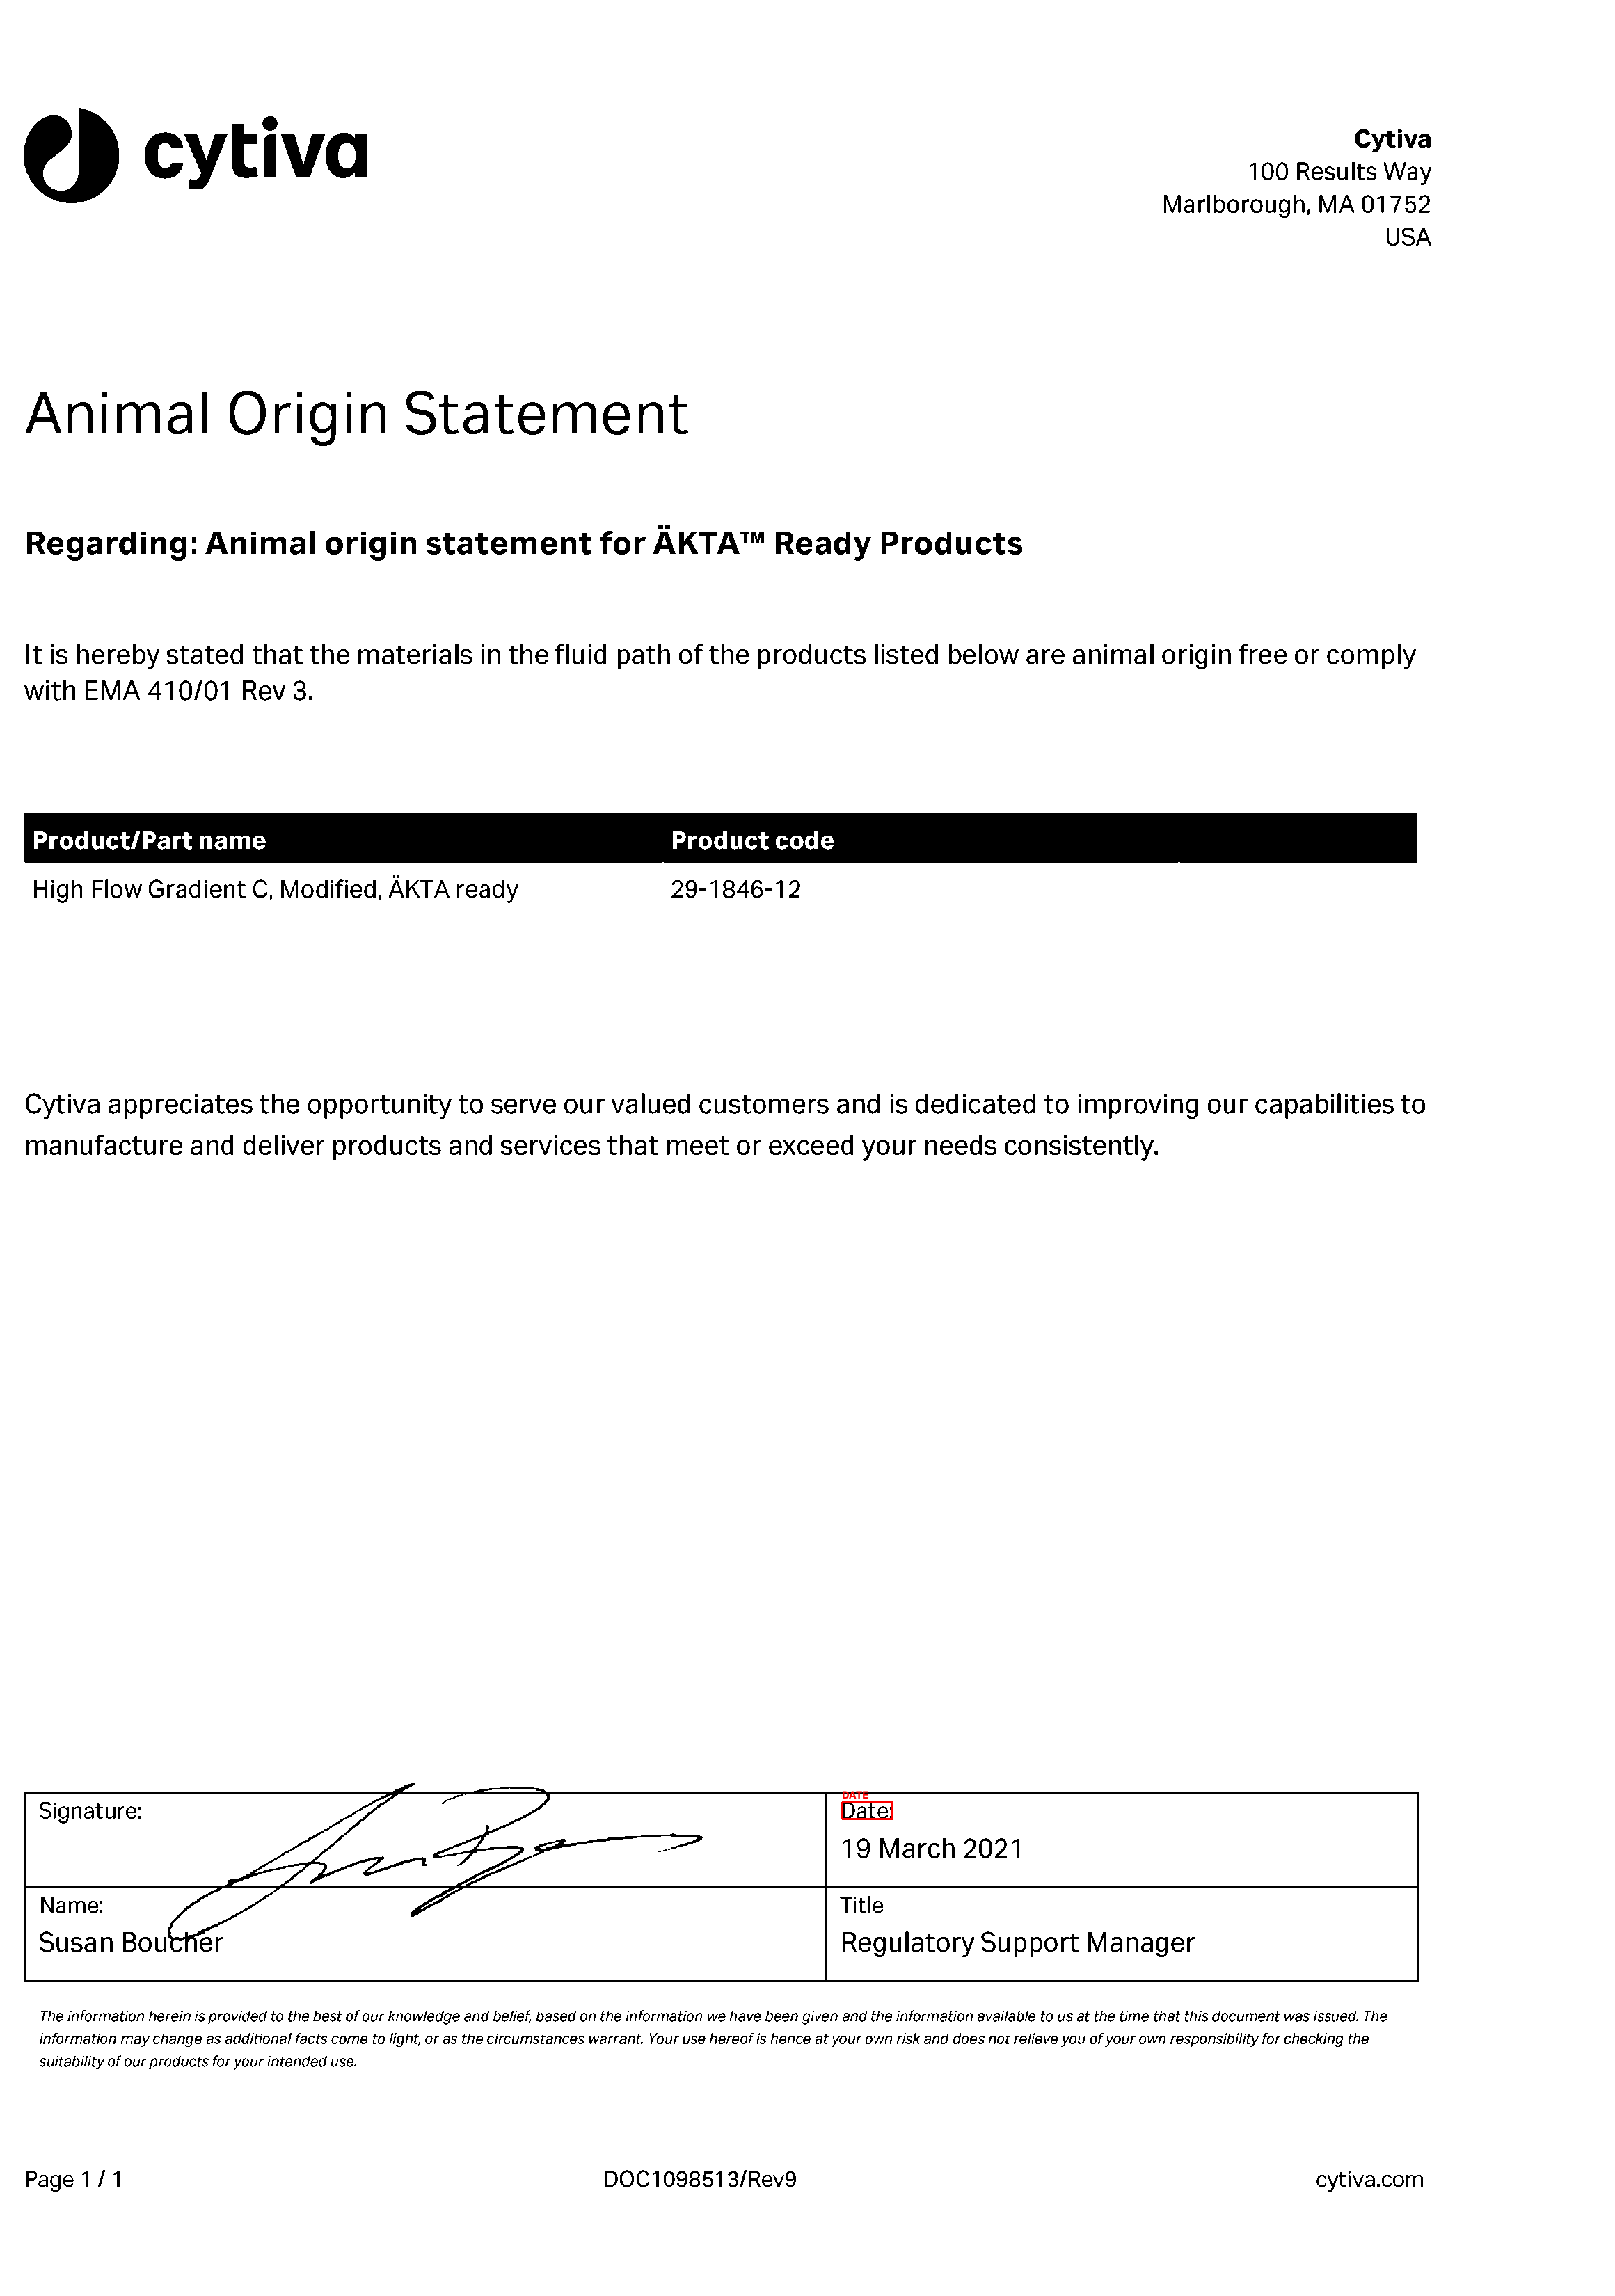

{
    "DATE": [
        {
            "text": "DATE:",
            "bounding_box": [
                1210,
                2590,
                72,
                24
            ],
            "conf": 96
        }
    ]
}


In [ ]:
def get_pages(path,dpi=300):
  doc=fitz.open(path)
  for page in doc:
    pix=page.get_pixmap(dpi=dpi)
    yield np.array(Image.open(io.BytesIO(pix.tobytes("png"))).convert("RGB"))


def make_gray(page):
  return cv2.cvtColor(page,cv2.COLOR_RGB2GRAY)


def image_thresholding(gray):
  _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
  return th

def noise_filtering(threshold):
  return threshold
  #return cv2.bilateralFilter(threshold,9,75,75) implementation works better without noise filtering.

def standard_corrections(text):
  text = re.sub(r'\bL0T\b', 'LOT',text, flags=re.IGNORECASE)
  text = re.sub(r'\bC0A\b', 'COA', text, flags=re.IGNORECASE)
  text = re.sub(r'\bCERT1FICATE\b', 'CERTIFICATE',text, flags=re.IGNORECASE)
  text = re.sub(r'\bEXP1RATION\b', 'EXPIRATION', text, flags=re.IGNORECASE)
  text = re.sub(r'[|_+]', '',text)
  return text

def split_sidebar(thresh, frac=0.09):
    cut = int(thresh.shape[1] * frac)
    return thresh[:, cut:], thresh[:, :cut]

key_fields = ["CERTIFICATE", "LOT", "BATCH", "VENDOR", "EXPIRATION", "DATE", "SIGNATURE", "COA", "MANUFACTURER"]

pages=get_pages("data.pdf")
for i,page in enumerate(pages,1):
  gray=make_gray(page)
  clean=noise_filtering(gray)
  thresh=image_thresholding(clean)
  main_body, sidebar = split_sidebar(thresh)

  # Step 6-7: OCR + clean
  body_text = pytesseract.image_to_string(main_body, config="--oem 3 --psm 6")
  out = " ".join(body_text.split())
  out = standard_corrections(out)

  print(f"---Page {i} ----")
  print(out)

  # Step 8: pull specific known fields out of the cleaned text (edit these
  # patterns to match whatever fields this particular document type has)
  run_id_match = re.search(r"Gamma\s*Process\s*Run\s*ID[:\s]*([\w\-]+)", out, re.IGNORECASE)
  if run_id_match:
      print(f"Extracted Gamma Process Run ID: {run_id_match.group(1)}")

  lot_matches = re.findall(r"\b(\d{8})\b", out)
  if lot_matches:
      print(f"Extracted Product Lot Numbers: {lot_matches}")

  # Step 9: bounding boxes -- run on main_body, since that's the image OCR
  # actually ran on, so coordinates line up
  ocr_data = pytesseract.image_to_data(main_body, config="--oem 3 --psm 6", output_type=pytesseract.Output.DICT)
  for j in range(min(5, len(ocr_data["text"]))):
      print(f"Word: {ocr_data['text'][j]}, BBox: ({ocr_data['left'][j]}, {ocr_data['top'][j]}, {ocr_data['width'][j]}, {ocr_data['height'][j]})")

  # Step 10: draw all detected words above a confidence threshold
  img_bgr_all = cv2.cvtColor(main_body, cv2.COLOR_GRAY2BGR)
  confidence_threshold = 40
  for j in range(len(ocr_data["text"])):
      word = ocr_data["text"][j].strip()
      conf = int(ocr_data["conf"][j])
      if not word or conf < confidence_threshold:
          continue
      x, y, w, h = ocr_data["left"][j], ocr_data["top"][j], ocr_data["width"][j], ocr_data["height"][j]
      cv2.rectangle(img_bgr_all, (x, y), (x + w, y + h), (0, 255, 0), 2)
      cv2.putText(img_bgr_all, word, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
  display(Image.fromarray(cv2.cvtColor(img_bgr_all, cv2.COLOR_BGR2RGB)))

  # Step 11: highlight only key fields (bonus: substring match, not exact ==)
  img_bgr_keys = cv2.cvtColor(main_body, cv2.COLOR_GRAY2BGR)
  for j in range(len(ocr_data["text"])):
      word = ocr_data["text"][j].strip().upper()
      if not word:
          continue
      matched = next((key for key in key_fields if key in word), None)
      if matched:
          x, y, w, h = ocr_data["left"][j], ocr_data["top"][j], ocr_data["width"][j], ocr_data["height"][j]
          cv2.rectangle(img_bgr_keys, (x, y), (x + w, y + h), (0, 0, 255), 2)
          cv2.putText(img_bgr_keys, matched, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
  display(Image.fromarray(cv2.cvtColor(img_bgr_keys, cv2.COLOR_BGR2RGB)))

  # Step 12: structure key fields as JSON (bonus: confidence scores included,
  # list per key so repeated fields like "DATE" aren't overwritten)
  extracted_data = {}
  for j in range(len(ocr_data["text"])):
      word = ocr_data["text"][j].strip().upper()
      if not word:
          continue
      matched = next((key for key in key_fields if key in word), None)
      if matched:
          x, y, w, h = ocr_data["left"][j], ocr_data["top"][j], ocr_data["width"][j], ocr_data["height"][j]
          extracted_data.setdefault(matched, []).append({
              "text": word,
              "bounding_box": [x, y, w, h],
              "conf": int(ocr_data["conf"][j])
          })

  print(json.dumps(extracted_data, indent=4))